In [44]:
##importing packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
from statsmodels.gam.api import GLMGam, BSplines
from statsmodels.stats.anova import anova_lm




In [45]:
#importing our dataset

hw_3_data = pd.read_csv("../../SCCS2_v12.csv")


print(hw_3_data.head())
print(hw_3_data.columns.tolist())
print(hw_3_data["gender"].value_counts())  
print(hw_3_data.isna().sum())

   Unnamed: 0  caseID  ethnic      height     weight      waist    hip    tc  \
0           1      23       1  177.350006  58.000000  69.500000  92.00  4.65   
1           2      39       1  173.350006  64.099998  75.550003  95.50  6.26   
2           3      42       1  177.100006  52.200001  63.000000  89.00  4.81   
3           4      51       1  167.800003  59.700001  72.000000  92.75  5.06   
4           5      68       1  172.300003  65.699997  72.500000  99.00  4.85   

     tg   hdl  ...  diabetes  hypertension  educ  drink  smoke  gender  \
0  0.54  1.07  ...         0             1   3.0      1      1       0   
1  1.20  1.20  ...         0             1   2.0      1      1       0   
2  0.79  1.64  ...         0             1   5.0      0      1       0   
3  2.19  1.13  ...         0             1   5.0      1      1       0   
4  1.35  1.15  ...         0             1   3.0      1      1       0   

   alcohol        age  ihd  Dummy2  
0        2  35.972622    0       2  


In [46]:
#building out 
analytic = hw_3_data.dropna(subset=["tc", "age"]).copy()
analytic["age_squared"] = analytic["age"] ** 2
analytic["age_cubed"] = analytic["age"] ** 3



In [47]:
#now that we have our columns built out, let;s make some models

y = analytic["tc"]

m_i = sm.OLS(y, sm.add_constant(analytic[["age"]])).fit()
m_ii = sm.OLS(y, sm.add_constant(analytic[["age", "age_squared"]])).fit()





In [48]:
#lets built out the spline model

#first line is for the knots I made in Q1

a1, a2 = analytic["age"].quantile([1/3, 2/3])

#note, these are cubic splines per the problem
analytic["knot1"] = np.clip(analytic["age"] - a1, 0, None) ** 3
analytic["knot2"] = np.clip(analytic["age"] - a2, 0, None) ** 3

X_iii = sm.add_constant(analytic[["age", "age_squared", "age_cubed", "knot1", "knot2"]])
m_iii = sm.OLS(y, X_iii).fit()
print("Knots:", round(a1, 1), round(a2, 1))

Knots: 35.4 50.7


In [49]:
#now lets build out the GAM model
#we are going have to make a fucntion here to run the regression on each data point

bs = BSplines(analytic[["age"]], df=[10], degree=[3])

def edf_age(alpha):
    fit = GLMGam.from_formula("tc ~ 1", data=analytic, smoother=bs, alpha=[alpha]).fit()
    return fit.edf.sum() - 1


alphas = np.logspace(-2, 6, 200)
edfs = np.array([edf_age(a) for a in alphas])
best_alpha = alphas[np.argmin(np.abs(edfs - 4))]

m_iv = GLMGam.from_formula("tc ~ 1", data=analytic, smoother=bs, alpha=[best_alpha]).fit()
print("alpha:", round(best_alpha, 2), " effective df for age:", round(edf_age(best_alpha), 2))

alpha: 2221.95  effective df for age: 4.01


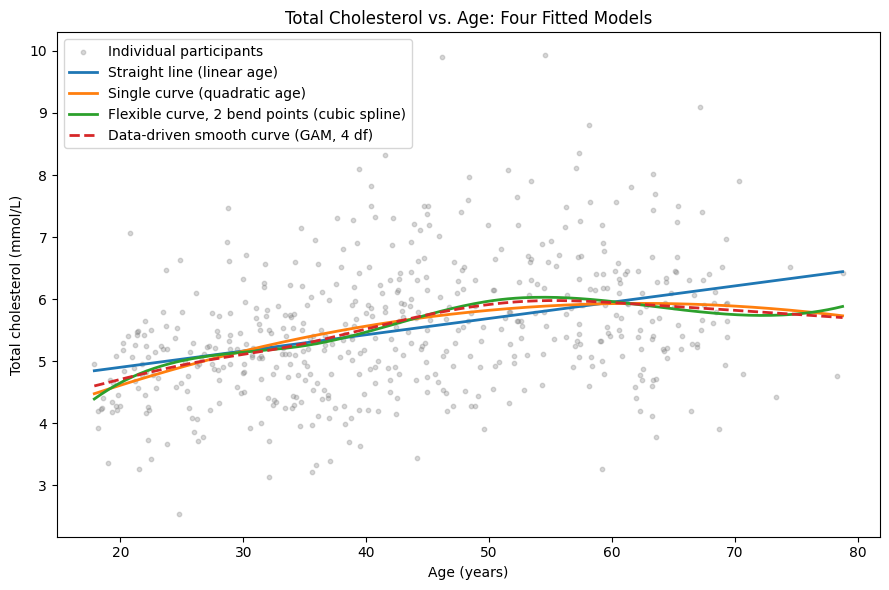

In [50]:
#now let's plot our functions

grid = pd.DataFrame({"age": np.linspace(analytic["age"].min(), analytic["age"].max(), 200)})
grid["age_squared"] = grid["age"] ** 2
grid["age_cubed"] = grid["age"] ** 3
grid["knot1"] = np.clip(grid["age"] - a1, 0, None) ** 3
grid["knot2"] = np.clip(grid["age"] - a2, 0, None) ** 3


#lets organize our model predictions


pred_i = m_i.predict(sm.add_constant(grid[["age"]]))
pred_ii = m_ii.predict(sm.add_constant(grid[["age", "age_squared"]]))
pred_iii = m_iii.predict(sm.add_constant(grid[["age", "age_squared", "age_cubed", "knot1", "knot2"]]))
pred_iv = m_iv.predict(exog=grid, exog_smooth=grid[["age"]])



#and then finally we can plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(analytic["age"], analytic["tc"], s=10, alpha=0.3, color="gray", label="Individual participants")
ax.plot(grid["age"], pred_i, color="tab:blue", lw=2, label="Straight line (linear age)")
ax.plot(grid["age"], pred_ii, color="tab:orange", lw=2, label="Single curve (quadratic age)")
ax.plot(grid["age"], pred_iii, color="tab:green", lw=2, label="Flexible curve, 2 bend points (cubic spline)")
ax.plot(grid["age"], pred_iv, color="tab:red", lw=2, linestyle="--", label="Data-driven smooth curve (GAM, 4 df)")


ax.set_xlabel("Age (years)")
ax.set_ylabel("Total cholesterol (mmol/L)")
ax.set_title("Total Cholesterol vs. Age: Four Fitted Models")
ax.legend()

plt.tight_layout()
plt.savefig("hw_3_fitted_curves.pdf")
plt.show()

In [51]:
#we have to use the same logic to calculate the r squared value for GAM. Could be a good indcattion to use R in the future

sst = ((y - y.mean()) ** 2).sum()
n_obs = len(y)

def fit_row(name, llf, k, ssr):
    return {"model": name, "params": round(k, 2), "R2": 1 - ssr / sst,
            "AIC": -2 * llf + 2 * k, "BIC": -2 * llf + np.log(n_obs) * k}


rows = [
    fit_row("i. linear", m_i.llf, m_i.df_model + 1, m_i.ssr),
    fit_row("ii. quadratic", m_ii.llf, m_ii.df_model + 1, m_ii.ssr),
    fit_row("iii. cubic spline", m_iii.llf, m_iii.df_model + 1, m_iii.ssr),
    fit_row("iv. GAM", m_iv.llf, m_iv.edf.sum(), m_iv.deviance),
]
fit_table = pd.DataFrame(rows)
fit_table["adj_R2"] = [m_i.rsquared_adj, m_ii.rsquared_adj, m_iii.rsquared_adj, np.nan]
print(fit_table.round(4))

#now lets see our p vlaues

print(anova_lm(m_i, m_ii, m_iii))

               model  params      R2        AIC        BIC  adj_R2
0          i. linear    2.00  0.1298  1476.3925  1484.9269  0.1281
1      ii. quadratic    3.00  0.1505  1465.7157  1478.5173  0.1472
2  iii. cubic spline    6.00  0.1588  1466.5021  1492.1053  0.1508
3            iv. GAM    5.01  0.1574  1465.3933  1486.7570     NaN
   df_resid         ssr  df_diff    ss_diff          F    Pr(>F)
0     525.0  504.333234      0.0        NaN        NaN       NaN
1     524.0  492.346379      1.0  11.986855  12.810578  0.000377
2     521.0  487.499584      3.0   4.846795   1.726620  0.160503


In [52]:
analytic["age_linear"] = analytic["age"]
X_dup = sm.add_constant(analytic[["age", "age_squared", "age_cubed", "knot1", "knot2", "age_linear"]])
m_iii_dup = sm.OLS(y, X_dup).fit()

print(m_iii_dup.params.round(5))
print("df_model:", m_iii.df_model, "vs", m_iii_dup.df_model)
print("adj R2:", m_iii.rsquared_adj, "vs", m_iii_dup.rsquared_adj)
print("AIC:", m_iii.aic, "vs", m_iii_dup.aic)
print(anova_lm(m_iii, m_iii_dup))

const         -2.65480
age            0.36211
age_squared   -0.02289
age_cubed      0.00025
knot1         -0.00041
knot2          0.00026
age_linear     0.36211
dtype: float64
df_model: 5.0 vs 5.0
adj R2: 0.15076977799146207 vs 0.15076977799146218
AIC: 1466.5020579627003 vs 1466.5020579627003
   df_resid         ssr  df_diff       ss_diff    F  Pr(>F)
0     521.0  487.499584      0.0           NaN  NaN     NaN
1     521.0  487.499584     -0.0  1.136868e-13 -inf     NaN


/var/folders/r9/024r7wqn2kz5lxf3czsr79851408l0/T/ipykernel_73553/437780146.py:3: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m_iii_dup = sm.OLS(y, X_dup).fit()


In [53]:
#now we are adding age and age squared to see if it is still nested

analytic["age_dup"] = analytic["age"]
analytic["age_squared_dup"] = analytic["age_squared"]

X_iii_B = sm.add_constant(analytic[["age", "age_squared", "age_cubed", "knot1", "knot2",
                                    "age_dup", "age_squared_dup"]])
m_iii_B = sm.OLS(y, X_iii_B).fit()




print(m_iii_B.params.round(5))
print("df_model:", m_iii.df_model, "vs", m_iii_B.df_model)
print("adj R2:", m_iii.rsquared_adj, "vs", m_iii_B.rsquared_adj)
print("AIC:", m_iii.aic, "vs", m_iii_B.aic)
print(anova_lm(m_iii, m_iii_B))

const             -2.65480
age                0.36211
age_squared       -0.01145
age_cubed          0.00025
knot1             -0.00041
knot2              0.00026
age_dup            0.36211
age_squared_dup   -0.01145
dtype: float64
df_model: 5.0 vs 5.0
adj R2: 0.15076977799146207 vs 0.15076977799146152
AIC: 1466.5020579627003 vs 1466.5020579627005
   df_resid         ssr  df_diff       ss_diff    F  Pr(>F)
0     521.0  487.499584      0.0           NaN  NaN     NaN
1     521.0  487.499584     -0.0 -2.842171e-13  inf     NaN


/var/folders/r9/024r7wqn2kz5lxf3czsr79851408l0/T/ipykernel_73553/3827058452.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m_iii_B = sm.OLS(y, X_iii_B).fit()


In [54]:
#ok now we are bringing in our hypothesis testing. We will start w our full model and then reduce it down

full = m_iii

#now we need to use some ANOVA for question ii

print(anova_lm(m_ii, m_iii))

   df_resid         ssr  df_diff   ss_diff        F    Pr(>F)
0     524.0  492.346379      0.0       NaN      NaN       NaN
1     521.0  487.499584      3.0  4.846795  1.72662  0.160503


In [ ]:
#ok for question 2, we are building out a more home made model that will require BMI

height_meters = hw_3_data["height"] / 100
hw_3_data["bmi"] = hw_3_data["weight"] / (height_meters ** 2)

# we are going to need a new data set for relevant columns with no NA values
q2 = hw_3_data.dropna(subset=["tc", "age", "bmi", "gender"]).copy()
#finally, we are going to need our age square value

q2["age_squared"] = q2["age"] ** 2
print(len(q2), "people in the Question 2 sample")




527 people in the Question 2 sample


In [60]:
# ok now we are going to build out models in increasing order. Starting w the crude model

y_q2 = q2["tc"]

X_crude = sm.add_constant(q2[["bmi"]])
m_crude = sm.OLS(y_q2, X_crude).fit()
print(m_crude.summary())

#then lets add our age squared value

X_age = sm.add_constant(q2[["bmi", "age", "age_squared"]])
m_age = sm.OLS(y_q2, X_age).fit()
print(m_age.summary())


                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     32.70
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           1.80e-08
Time:                        13:23:35   Log-Likelihood:                -756.91
No. Observations:                 527   AIC:                             1518.
Df Residuals:                     525   BIC:                             1526.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1100      0.250     16.435      0.0

In [61]:
#now lets do a more complex model w age and a age squared value

X_age = sm.add_constant(q2[["bmi", "age", "age_squared"]])
m_age = sm.OLS(y_q2, X_age).fit()
print(m_age.summary())


                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     34.39
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.68e-20
Time:                        13:24:16   Log-Likelihood:                -725.39
No. Observations:                 527   AIC:                             1459.
Df Residuals:                     523   BIC:                             1476.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.6352      0.414      6.371      

In [63]:
#now lets bring in gender
X_age_sex = sm.add_constant(q2[["bmi", "age", "age_squared", "gender"]])
m_age_sex = sm.OLS(y_q2, X_age_sex).fit()
print(m_age_sex.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     25.99
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           1.15e-19
Time:                        13:25:32   Log-Likelihood:                -724.97
No. Observations:                 527   AIC:                             1460.
Df Residuals:                     522   BIC:                             1481.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.6224      0.414      6.335      

In [64]:
#ok now that we have our models, we can make a dataframe to compare the values

bmi_compare = pd.DataFrame({
    "bmi_coef": [m_crude.params["bmi"], m_age.params["bmi"], m_age_sex.params["bmi"]],
    "p_value": [m_crude.pvalues["bmi"], m_age.pvalues["bmi"], m_age_sex.pvalues["bmi"]],
}, index=["crude", "+ age, age2", "+ age, age2, sex"])
bmi_compare["pct_change_from_crude"] = 100 * (bmi_compare["bmi_coef"] - m_crude.params["bmi"]) / m_crude.params["bmi"]
print(bmi_compare.round(4))

                  bmi_coef  p_value  pct_change_from_crude
crude               0.0582   0.0000                 0.0000
+ age, age2         0.0305   0.0029               -47.5950
+ age, age2, sex    0.0299   0.0037               -48.7015


In [65]:
#now we bring in effect modificaiton

q2["bmi_gender"] = q2["bmi"] * q2["gender"]

X_em = sm.add_constant(q2[["bmi", "gender", "bmi_gender", "age", "age_squared"]])
m_em = sm.OLS(y_q2, X_em).fit()
print(m_em.summary())

print(anova_lm(m_age_sex, m_em))

b = m_em.params
print(f"Males:   BMI slope = {b['bmi']:.4f}")
print(f"Females: BMI slope = {b['bmi'] + b['bmi_gender']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     20.85
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           5.15e-19
Time:                        13:35:07   Log-Likelihood:                -724.76
No. Observations:                 527   AIC:                             1462.
Df Residuals:                     521   BIC:                             1487.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.4450      0.498      4.906      

In [66]:
#looks like age squared is best

print(m_age.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     34.39
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.68e-20
Time:                        13:42:05   Log-Likelihood:                -725.39
No. Observations:                 527   AIC:                             1459.
Df Residuals:                     523   BIC:                             1476.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.6352      0.414      6.371      

In [71]:
#we need to see if our model fits the classical definition of a confounder

m_bmi_age = sm.OLS(q2["bmi"], sm.add_constant(q2[["age", "age_squared"]])).fit()
print("Age to BMI: F p-value =", m_bmi_age.f_pvalue)

m_bmi_sex = sm.OLS(q2["bmi"], sm.add_constant(q2[["gender"]])).fit()
print("Sex to BMI: p-value =", m_bmi_sex.pvalues["gender"])

print(m_age.summary())

print(m_age_sex.pvalues["gender"])

q2["age_cubed"] = q2["age"] ** 3
q2["knot1"] = np.clip(q2["age"] - a1, 0, None) ** 3
q2["knot2"] = np.clip(q2["age"] - a2, 0, None) ** 3

X_spline_q2 = sm.add_constant(q2[["bmi", "age", "age_squared", "age_cubed", "knot1", "knot2"]])
m_spline_q2 = sm.OLS(y_q2, X_spline_q2).fit()

print(anova_lm(m_age, m_spline_q2))

anova_lm(m_age, m_spline_q2)

Age to BMI: F p-value = 1.967527572073344e-14
Sex to BMI: p-value = 0.21604033321423757
                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     34.39
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.68e-20
Time:                        13:53:26   Log-Likelihood:                -725.39
No. Observations:                 527   AIC:                             1459.
Df Residuals:                     523   BIC:                             1476.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,523.0,484.072153,0.0,NaN,NaN,NaN
1,520.0,478.966934,3.0,5.105219,1.847528,0.137534


In [ ]:
#now we need to use american units
conv = 38.67
est = m_age.params["bmi"] * conv
ci_low, ci_high = m_age.conf_int().loc["bmi"] * conv
print(f"BMI effect: {est:.2f} mg/dL (95% CI: {ci_low:.2f}, {ci_high:.2f}), p = {m_age.pvalues['bmi']:.3f}")

BMI effect: 1.18 mg/dL (95% CI: 0.40, 1.96), p = 0.003
